In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector


db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Nirmal@2005',
    database='ecomerse'
)

cur = db.cursor()

#its all unique cities where customers are located

In [36]:
query = """select distinct customer_city from customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['customer_city'])
df.head()

,customer_city
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


count the number of orders placed in 2017

In [11]:
query = """select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query)

data = cur.fetchall()

"total orders in 2017: ", data[0][0]

('total orders in 2017: ', 135303)

find the total sales pr category

In [16]:
query = """select upper(products.product_category) category, sum(payments.payment_value) sales
from products join order_items 
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['category', 'sales'])
df



,category,sales
0,PERFUMERY,6.080864e+06
1,FURNITURE DECORATION,1.716212e+07
2,TELEPHONY,5.842585e+06
3,BED TABLE BATH,2.055064e+07
4,AUTOMOTIVE,1.022753e+07
...,...,...
69,CDS MUSIC DVDS,1.439316e+04
70,LA CUISINE,3.496236e+04
71,FASHION CHILDREN'S CLOTHING,9.428040e+03
72,PC GAMER,2.609316e+04


calculate the percentage pf orders that were paid inn installments

In [22]:
query = """select sum(case when payment_installments >= 1 then 1 else 0 end)
/count(*)*100 
from payments
"""

cur.execute(query)

data = cur.fetchall()
"the percentage of orders that were paid in installments: ", data[0][0]

('the percentage of orders that were paid in installments: ',
 Decimal('99.9981'))

cunt the number of customers from each state

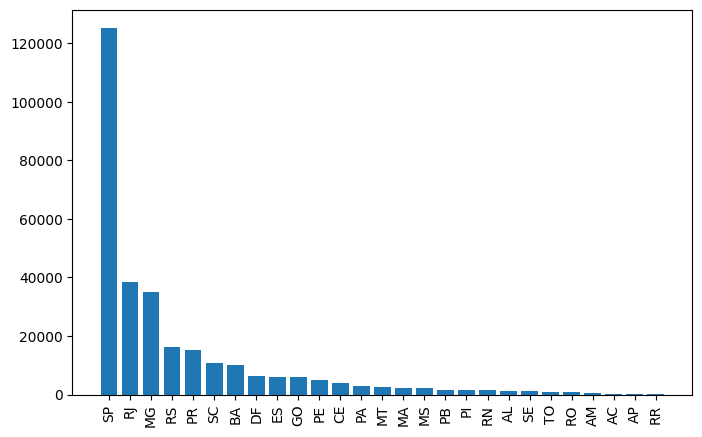

In [34]:
query = """select customer_state, count(customer_id) 
from customers group by customer_state 
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['state', 'customer_count'])
df = df.sort_values(by = "customer_count", ascending = False )

plt.figure(figsize=(8,5))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation=90)
plt.show()

calculate the number of orders pr monyh in 2018

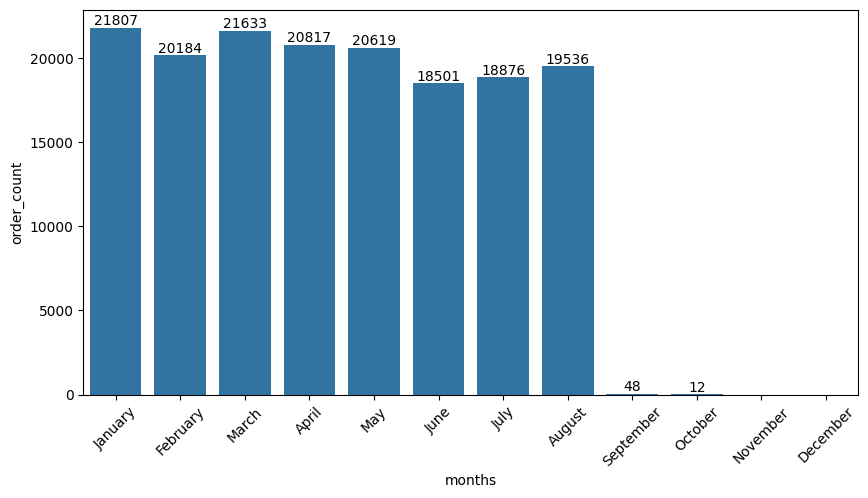

In [4]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018 
group by months
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['months', 'order_count'])
plt.figure(figsize=(10,5))
o = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

ax = sns.barplot(x = df["months"], y = df["order_count"], data = df, order = o)
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0])
plt.show()

find the average number of product per order, grouped by customer city

In [18]:
query = """ with count_per_order as
(SELECT orders.order_id, orders.customer_id, count(order_items.order_id)
as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns=['customer_city', 'average_orders'])
df

,customer_city,average_orders
0,padre carvalho,42.00
1,celso ramos,39.00
2,datas,36.00
3,candido godoi,36.00
4,matias olimpio,30.00
...,...,...
4105,tuiuti,6.00
4106,tibau do sul,6.00
4107,sao mamede,6.00
4108,sambaiba,6.00


calculate the percentage of total revenue contributed by each product category.

In [24]:
query = """select upper(products.product_category) category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100, 2) sales_percentage
from products join order_items 
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns=['category', 'percentage_distribution'])
df

,category,percentage_distribution
0,BED TABLE BATH,64.19
1,HEALTH BEAUTY,62.12
2,COMPUTER ACCESSORIES,59.42
3,FURNITURE DECORATION,53.60
4,WATCHES PRESENT,53.57
...,...,...
69,PC GAMER,0.08
70,HOUSE COMFORT 2,0.06
71,CDS MUSIC DVDS,0.04
72,FASHION CHILDREN'S CLOTHING,0.03


identify the correlation between product price and the nukber of times a product has been purchased.

In [5]:
query = """SELECT products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=('product_category', 'product_count', 'average_price'))
df

,product_category,product_count,average_price
0,HEALTH BEAUTY,58020,130.16
1,sport leisure,51846,114.34
2,Cool Stuff,22776,167.36
3,computer accessories,46962,116.51
4,Watches present,35946,201.14
...,...,...,...
69,Kitchen portable and food coach,90,264.57
70,House Comfort 2,180,25.34
71,CITTE AND UPHACK FURNITURE,228,114.95
72,insurance and services,12,141.64


calculte the totl revenue generated by each celler,and rank them by revenue

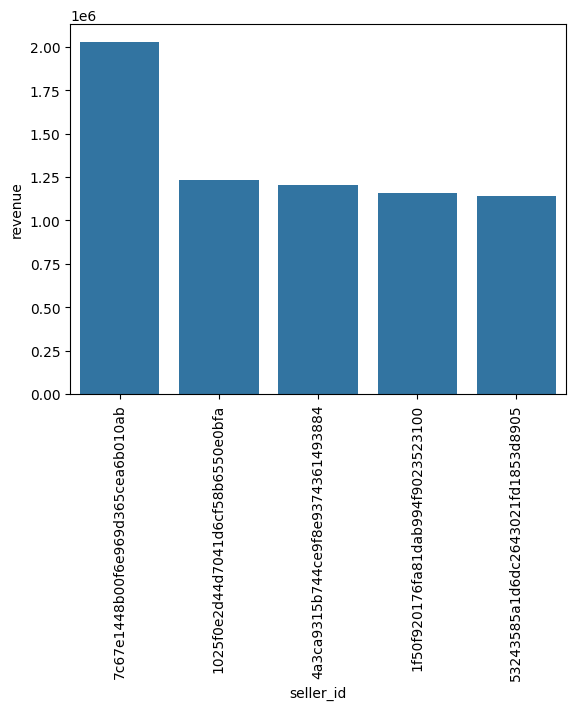

In [22]:
query  = """ select *, dense_rank() over (order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value) revenue
from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['seller_id', 'revenue', 'rank'])
df = df.head()
sns.barplot(x = "seller_id", y = "revenue", data = df)
plt.xticks(rotation=90)
plt.show()


calculate the moving average of order values of each customer over there orders history.

In [4]:
query = """ select customer_id, order_purchase_timestamp, payments,
avg(payments) over (partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row ) as mov_avg
from
(SELECT orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payments
from payments join orders
on payments.order_id = orders.order_id) as a;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['customer_id', 'order_purchase_timestamp', 'payments', 'moving_average'])
df

,customer_id,order_purchase_timestamp,payments,moving_average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
...,...,...,...,...
623311,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
623312,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
623313,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
623314,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


calculate the cumulative sales pr month for each year.

In [4]:
query = """ select years, months, payment,
sum(payment) over(order by years, months) cumulative_sales from
(select year(orders.order_purchase_timestamp) as years,
monthname(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value), 2) as payment from payments
join orders
on payments.order_id = orders.order_id
group by years, months order by years, months) as a 
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['years', 'months', 'payment', 'cumulative_sales'])
df

,years,months,payment,cumulative_sales
0,2016,December,117.72,117.72
1,2016,October,354542.88,354660.60
2,2016,September,1513.44,356174.04
3,2017,April,2506728.18,2862902.22
4,2017,August,4046377.92,6909280.14
5,2017,December,5270408.88,12179689.02
6,2017,February,1751448.06,13931137.08
7,2017,January,830928.24,14762065.32
8,2017,July,3554297.52,18316362.84
9,2017,June,3067658.28,21384021.12


calculat the year-over-year growth rate of total sales.

In [15]:
query = """ with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value), 2) as payment from payments
join orders
on payments.order_id = orders.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years)) /
lag(payment, 1) over(order by years)) * 100 from a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['years', 'yoy % growth'])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703759
2,2018,20.000924


calculate the retentation of customers, defined ass the perrcentages of customers who make anotherr purchase within 6 months of their first purchase.

In [16]:
query = """ with a as (SELECT customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and order_purchase_timestamp > first_order
and order_purchase_timestamp <
date_add(first_order, interval 3 month)
group by a.customer_id)

select 100 * (count(distinct a.customer_id)/ count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id
;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['percentage_of_customers_with_second_order_within_3_months'])
df

,percentage_of_customers_with_second_order_within_3_months
0,None


identify the top 3 customers who spend the most money in each year.

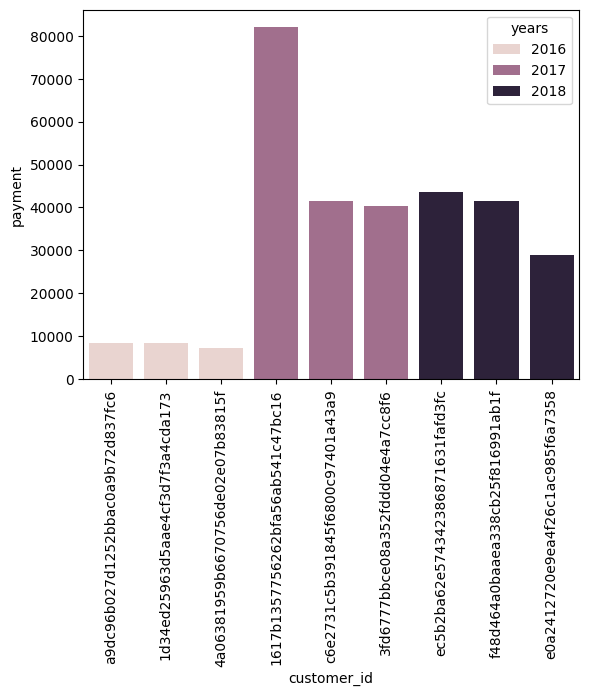

In [9]:
query = """ select years, customer_id, payment, d_rank
 from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp) 
order by sum(payments.payment_value) desc ) d_rank
from orders join payments
on orders.order_id = payments.order_id
group by (orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['years', 'customer_id', 'payment', 'rank'])
sns.barplot(x = "customer_id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()
